# Longitudinal Exposure Graph: AI Score & Comment Sentiment Over Time

This notebook visualises **within-project dynamics** of AI-generated text in
updates and backer sentiment in comments, over **calendar months**.

It reuses the same data loading and sample construction as
`did_analysis_systematic.ipynb` (Steps 1–5) so the project set and
covariates are identical to the DID regressions.

## Workflow
1. Load & prepare the cross-sectional DID sample (`df_analysis`).
2. Build (or load) a **longitudinal panel** from scored updates/comments.
3. Filter the panel to the DID project set, merge covariates.
4. **Cell A** — plot one project.
5. **Cell B** — plot a small sample of projects.

In [1]:
# Step 1: Load Libraries, Clean Data, and Create Features
# (Replicated from did_analysis_systematic.ipynb Steps 1–5)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from plot_exposure_graph import (
    assign_time_bin,
    aggregate_panel,
    filter_panel_to_did_projects,
    merge_did_covariates,
    plot_ai_timeseries,
    plot_sentiment_timeseries,
    plot_combined_ai_sentiment,
    plot_combined_faceted,
)


def _repo_root() -> Path:
    """Find repo root (directory containing data/processed/)."""
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "data" / "processed").is_dir():
            return p
        p = p.parent
    return Path.cwd().resolve()


DEBERTA_PKL = _repo_root() / "data" / "processed" / "final_with_deberta_ai_score_20251003_151656.pkl"
if not DEBERTA_PKL.is_file():
    raise FileNotFoundError(
        f"Expected pickle at {DEBERTA_PKL}. Run from repo root or place the file under data/processed/."
    )

# Load data with AI detection scores
df = pd.read_pickle(DEBERTA_PKL)
print(f"Loaded {len(df):,} projects from {DEBERTA_PKL}")

# Impute missing goals
impute_mask = (
    (df['platform'] == 'Indiegogo') &
    (df['goal'].isna()) &
    (df['pledged'].notna()) &
    (df['pledged'] > 0) &
    (df['funds_raised_percent'].notna()) &
    (df['funds_raised_percent'] > 0)
)
df.loc[impute_mask, 'goal'] = (
    df.loc[impute_mask, 'pledged'] / (df.loc[impute_mask, 'funds_raised_percent'] / 100)
)

# Unified funding percent and success indicator
df['funding_percent'] = np.nan
ks_mask = df['platform'] == 'Kickstarter'
ig_mask = df['platform'] == 'Indiegogo'
df.loc[ks_mask, 'funding_percent'] = df.loc[ks_mask, 'percent_funded']
df.loc[ig_mask, 'funding_percent'] = df.loc[ig_mask, 'funds_raised_percent']
df['success_indicator'] = (
    (df['funding_percent'] >= 100) | (df['state'] == 'successful')
).astype(int)

# Parse dates
def clean_timezone(date_str):
    if pd.isna(date_str):
        return pd.NaT
    return re.sub(r'[+-]\\d{2}:\\d{2}$', '', str(date_str))

df['created_at_parsed'] = pd.to_datetime(df['created_at'].apply(clean_timezone), errors='coerce')

# Outcome
df.loc[ks_mask, 'pledged_amount_usd'] = (df.loc[ks_mask, 'percent_funded'] / 100 * df.loc[ks_mask, 'goal']).fillna(0)
df.loc[ig_mask, 'pledged_amount_usd'] = (df.loc[ig_mask, 'funds_raised_percent'] / 100 * df.loc[ig_mask, 'goal']).fillna(0)
df['log_pledged_amount'] = np.log(df['pledged_amount_usd'].clip(lower=1))

Loaded 64,488 projects from C:\Users\Ben\Documents\GitHub\crowdsourcing\data\processed\final_with_deberta_ai_score_20251003_151656.pkl


In [2]:
# Step 2: Create unified categories (same mapping as DID notebook)

ks_mapping = {
    'Illustration': 'Creative_Visual_Arts', 'Digital Art': 'Creative_Visual_Arts', 'Art': 'Creative_Visual_Arts',
    'Animation': 'Creative_Visual_Arts', 'Painting': 'Creative_Visual_Arts', 'Sculpture': 'Creative_Visual_Arts',
    'Photography': 'Creative_Visual_Arts', 'Mixed Media': 'Creative_Visual_Arts', 'Design': 'Creative_Visual_Arts',
    'Fine Art': 'Creative_Visual_Arts', 'Public Art': 'Creative_Visual_Arts',
    'Comic Books': 'Publishing_Writing', 'Graphic Novels': 'Publishing_Writing', 'Fiction': 'Publishing_Writing',
    'Nonfiction': 'Publishing_Writing', 'Anthologies': 'Publishing_Writing', 'Zines': 'Publishing_Writing',
    'Poetry': 'Publishing_Writing', 'Literature': 'Publishing_Writing', 'Academic': 'Publishing_Writing',
    'Journals': 'Publishing_Writing', 'Comics': 'Publishing_Writing',
    'Product Design': 'Technology_Hardware', 'Hardware': 'Technology_Hardware', 'Apps': 'Technology_Hardware',
    'Gadgets': 'Technology_Hardware', 'DIY Electronics': 'Technology_Hardware', 'Wearables': 'Technology_Hardware',
    'Gaming Hardware': 'Technology_Hardware', 'Robotics': 'Technology_Hardware', '3D Printing': 'Technology_Hardware',
    'Software': 'Technology_Hardware', 'Technology': 'Technology_Hardware',
    'Playing Cards': 'Games_Toys', 'Tabletop Games': 'Games_Toys', 'Video Games': 'Games_Toys',
    'Mobile Games': 'Games_Toys', 'Live Games': 'Games_Toys', 'Puzzles': 'Games_Toys',
    'Toys': 'Games_Toys', 'Games': 'Games_Toys',
    'Shorts': 'Film_Music_Performance', 'Drama': 'Film_Music_Performance', 'Comedy': 'Film_Music_Performance',
    'Horror': 'Film_Music_Performance', 'Documentary': 'Film_Music_Performance', 'Music': 'Film_Music_Performance',
    'Rock': 'Film_Music_Performance', 'Hip-Hop': 'Film_Music_Performance', 'Pop': 'Film_Music_Performance',
    'Jazz': 'Film_Music_Performance', 'Classical Music': 'Film_Music_Performance', 'Country & Folk': 'Film_Music_Performance',
    'Electronic Music': 'Film_Music_Performance', 'Indie Rock': 'Film_Music_Performance', 'Theater': 'Film_Music_Performance',
    'Performance Art': 'Film_Music_Performance', 'Festivals': 'Film_Music_Performance', 'Film & Video': 'Film_Music_Performance',
    'Musical': 'Film_Music_Performance', 'Webseries': 'Film_Music_Performance', 'Television': 'Film_Music_Performance',
    'Radio & Podcasts': 'Film_Music_Performance', 'Audio': 'Film_Music_Performance', 'Narrative Film': 'Film_Music_Performance',
    'Dance': 'Film_Music_Performance', 'Sound': 'Film_Music_Performance', 'Blues': 'Film_Music_Performance',
    'World Music': 'Film_Music_Performance', 'Latin': 'Film_Music_Performance', 'Metal': 'Film_Music_Performance',
    'Punk': 'Film_Music_Performance', 'R&B': 'Film_Music_Performance',
    'Restaurants': 'Food_Lifestyle', 'Drinks': 'Food_Lifestyle', 'Food Trucks': 'Food_Lifestyle',
    'Vegan': 'Food_Lifestyle', 'Cookbooks': 'Food_Lifestyle', 'Candles': 'Food_Lifestyle',
    'Fashion': 'Food_Lifestyle', 'Apparel': 'Food_Lifestyle', 'Accessories': 'Food_Lifestyle',
    'Jewelry': 'Food_Lifestyle', 'Footwear': 'Food_Lifestyle', 'Cosmetics': 'Food_Lifestyle',
    'Food': 'Food_Lifestyle',
    'Community Gardens': 'Community_Education', 'Faith': 'Community_Education', 'Social Practice': 'Community_Education',
    'Events': 'Community_Education', 'Community': 'Community_Education',
}
ig_mapping = {
    'Art': 'Creative_Visual_Arts', 'Photography': 'Creative_Visual_Arts', 'Dance & Theater': 'Creative_Visual_Arts',
    'Web Series & TV Shows': 'Creative_Visual_Arts',
    'Comics': 'Publishing_Writing', 'Writing & Publishing': 'Publishing_Writing', 'Blogs/Podcasts/Vlogs': 'Publishing_Writing',
    'Productivity': 'Technology_Hardware', 'Phones & Accessories': 'Technology_Hardware', 'Energy & Green Tech': 'Technology_Hardware',
    'Smart Home': 'Technology_Hardware', 'Computers': 'Technology_Hardware', 'IoT': 'Technology_Hardware',
    'Security': 'Technology_Hardware', 'Drones': 'Technology_Hardware', 'VR/AR': 'Technology_Hardware',
    'Transportation': 'Technology_Hardware',
    'Tabletop Games': 'Games_Toys', 'Video Games': 'Games_Toys', 'Toys': 'Games_Toys',
    'Film': 'Film_Music_Performance', 'Music': 'Film_Music_Performance', 'Audio': 'Film_Music_Performance',
    'Web Series & TV': 'Film_Music_Performance', 'Dance & Theater': 'Film_Music_Performance',
    'Food & Beverages': 'Food_Lifestyle', 'Fashion & Wearables': 'Food_Lifestyle', 'Home': 'Food_Lifestyle',
    'Beauty': 'Food_Lifestyle', 'Health & Fitness': 'Food_Lifestyle', 'Wellness': 'Food_Lifestyle',
    'Education': 'Community_Education', 'Human Rights': 'Community_Education', 'Local Businesses': 'Community_Education',
    'Environment': 'Community_Education', 'Social Innovations': 'Community_Education', 'Culture': 'Community_Education',
}

df['category_unified'] = 'Other'
ks_m = df['platform'] == 'Kickstarter'
ig_m = df['platform'] == 'Indiegogo'
df.loc[ks_m, 'category_unified'] = df.loc[ks_m, 'category_name'].map(ks_mapping).fillna('Other')
df.loc[ig_m, 'category_unified'] = df.loc[ig_m, 'category_parent_name'].map(ig_mapping).fillna('Other')
print(f"\u2705 Created unified categories")
print(df['category_unified'].value_counts())

✅ Created unified categories
category_unified
Film_Music_Performance    15206
Other                     11130
Publishing_Writing         9461
Technology_Hardware        7332
Food_Lifestyle             7036
Creative_Visual_Arts       6832
Games_Toys                 5788
Community_Education        1703
Name: count, dtype: int64


In [3]:
# Step 3: Build df_analysis (same filters as DID notebook)

df_analysis_base = df.copy()
df_analysis_base['month'] = df_analysis_base['created_at_parsed'].dt.month
df_analysis_base['year'] = df_analysis_base['created_at_parsed'].dt.year

gpt_date = pd.Timestamp('2022-11-30')

df_analysis = df_analysis_base[
    (df_analysis_base['currency'] == 'USD') &
    (df_analysis_base['pledged'] > 0) &
    (df_analysis_base['text_quality'].notna()) &
    (df_analysis_base['platform'] == 'Kickstarter') &
    (df_analysis_base['created_at_parsed'].notna())
].copy()

df_analysis['PostGPT'] = (df_analysis['created_at_parsed'] > gpt_date).astype(int)
df_analysis['indiegogo'] = (df_analysis['platform'] == 'Indiegogo').astype(int)
df_analysis['log_goal'] = np.log(df_analysis['goal'].clip(lower=1))

print(f"\u2705 Analysis sample: {len(df_analysis):,} projects")
breakdown = pd.crosstab(df_analysis['platform'], df_analysis['PostGPT'], margins=True)
breakdown.columns = ['Pre-ChatGPT', 'Post-ChatGPT', 'Total']
print(breakdown)

✅ Analysis sample: 23,798 projects
             Pre-ChatGPT  Post-ChatGPT  Total
platform                                     
Kickstarter         7405         16393  23798
All                 7405         16393  23798


---
## Build the Longitudinal Panel from Analyzed Batch CSVs

The pipelines (`pipeline_updates.py`, `pipeline_comments.py`) save scored
batch CSVs to `data/analysis/`. Each update row has `ai_score_mean` (DeBERTa)
and `vader_compound` (VADER sentiment). Each comment row has `vader_compound`.

We load these, bin by calendar month, and merge into a single panel with
one row per **(project_id, time_bin)** carrying `ai_score_mean`,
`vader_compound` (from updates), and `comment_sentiment` (from comments).

In [11]:
# Build panel from pipeline_updates / pipeline_comments analyzed output.
# Output lives in data/analysis/ (see pipeline_updates.py, pipeline_comments.py).
#
# Updates cols: ..., published_at, project_id, ai_score_mean, vader_compound, ...
# Comments cols: ..., created_at, project_id, vader_compound, ...

import glob, os

ANALYSIS_DIR = str(_repo_root() / 'data' / 'analysis')

def load_and_bin(
    file_pattern,
    time_col_raw,
    score_cols,
    freq='M',
    text_col_candidates=None,
    word_count_col_name=None,
    panel_name='panel',
):
    """Load analyzed batch CSVs, assign time bins, and optionally add word counts."""
    files = sorted(glob.glob(file_pattern))
    if not files:
        print(f'No files found for pattern: {file_pattern}')
        return pd.DataFrame()

    dfs = [pd.read_csv(f) for f in files]
    raw = pd.concat(dfs, ignore_index=True)

    if 'id' in raw.columns:
        raw = raw.drop_duplicates(subset='id')

    raw = raw.dropna(subset=['project_id'])
    raw['project_id'] = raw['project_id'].astype(str)
    raw['time_bin'] = assign_time_bin(raw[time_col_raw], freq=freq)
    raw = raw.dropna(subset=['time_bin'])

    if text_col_candidates and word_count_col_name:
        text_col = next((c for c in text_col_candidates if c in raw.columns), None)
        if text_col:
            raw[word_count_col_name] = (
                raw[text_col]
                .fillna('')
                .astype(str)
                .str.findall(r"\b\w+\b")
                .str.len()
            )
            print(
                f"{panel_name}: using text column '{text_col}' for word counts "
                f"(total words={int(raw[word_count_col_name].sum()):,})"
            )
        else:
            print(f"{panel_name}: no text column found in candidates {text_col_candidates}")

    keep = ['project_id', 'time_bin'] + [c for c in score_cols if c in raw.columns]
    if word_count_col_name and word_count_col_name in raw.columns:
        keep.append(word_count_col_name)

    return raw[keep]

# --- Updates (AI score from DeBERTa sentence-level + VADER sentiment) ---
updates_panel = load_and_bin(
    os.path.join(ANALYSIS_DIR, 'updates_batch_*.csv'),
    time_col_raw='published_at',
    score_cols=['ai_score_mean', 'vader_compound'],
    text_col_candidates=['body', 'update_body', 'post_body', 'text', 'content'],
    word_count_col_name='update_word_count',
    panel_name='updates',
)

# --- Comments (VADER sentiment only — no AI detection) ---
comments_panel = load_and_bin(
    os.path.join(ANALYSIS_DIR, 'comments_batch_*.csv'),
    time_col_raw='created_at',
    score_cols=['vader_compound'],
    text_col_candidates=['body', 'comment', 'text', 'content'],
    word_count_col_name='comment_word_count',
    panel_name='comments',
)

# Quick totals across raw rows
if not updates_panel.empty and 'update_word_count' in updates_panel.columns:
    print(f"Updates total words: {int(updates_panel['update_word_count'].sum()):,}")
if not comments_panel.empty and 'comment_word_count' in comments_panel.columns:
    print(f"Comments total words: {int(comments_panel['comment_word_count'].sum()):,}")

# Aggregate each to (project_id, time_bin)
if not updates_panel.empty:
    updates_agg = aggregate_panel(
        updates_panel,
        score_cols=[
            c for c in ['ai_score_mean', 'vader_compound', 'update_word_count']
            if c in updates_panel.columns
        ],
    )
else:
    updates_agg = pd.DataFrame(columns=['project_id', 'time_bin', 'ai_score_mean', 'update_word_count'])

if not comments_panel.empty:
    comments_agg = aggregate_panel(
        comments_panel,
        score_cols=[c for c in ['vader_compound', 'comment_word_count'] if c in comments_panel.columns],
    )
    comments_agg = comments_agg.rename(columns={'vader_compound': 'comment_sentiment'})
else:
    comments_agg = pd.DataFrame(columns=['project_id', 'time_bin', 'comment_sentiment', 'comment_word_count'])

# Merge updates + comments on (project_id, time_bin)
if not updates_agg.empty and not comments_agg.empty:
    panel = updates_agg.merge(
        comments_agg[['project_id', 'time_bin', 'comment_sentiment', 'comment_word_count']],
        on=['project_id', 'time_bin'],
        how='outer',
    )
elif not updates_agg.empty:
    panel = updates_agg
else:
    panel = comments_agg

print(f"Panel: {len(panel):,} rows, {panel['project_id'].nunique():,} projects")
print(f"Columns: {list(panel.columns)}")
panel.head()

updates: using text column 'body' for word counts (total words=42,387,936)
comments: using text column 'body' for word counts (total words=22,550,480)
Updates total words: 42,387,936
Comments total words: 22,550,480
2026-04-20 09:10:49,871 - INFO - Aggregated panel: 133760 rows, 25402 projects, 54 time bins
2026-04-20 09:10:50,116 - INFO - Aggregated panel: 75591 rows, 16750 projects, 53 time bins
Panel: 167,155 rows, 26,873 projects
Columns: ['project_id', 'time_bin', 'ai_score_mean', 'vader_compound', 'update_word_count', '_obs_count', 'comment_sentiment', 'comment_word_count']


,project_id,time_bin,ai_score_mean,vader_compound,update_word_count,_obs_count,comment_sentiment,comment_word_count
0,1000022226,2024-07-01,0.397600,0.99360,155.0,1.0,NaN,NaN
1,1000022226,2024-08-01,0.068476,0.48425,53.0,2.0,0.924700,57.500
2,1000022226,2024-09-01,0.250863,0.87395,31.5,2.0,NaN,NaN
3,1000037534,2022-11-01,NaN,NaN,NaN,NaN,0.140969,21.000
4,1000037534,2022-12-01,0.572112,0.95200,450.0,1.0,0.309737,20.625


In [5]:
# Step 4: Filter panel to the DID sample and merge covariates

panel = filter_panel_to_did_projects(panel, df_analysis)
panel = merge_did_covariates(panel, df_analysis)

print(f"Panel after DID alignment: {len(panel):,} rows, {panel['project_id'].nunique():,} projects")
print(f"Columns: {list(panel.columns)}")

2026-04-20 08:56:32,190 - INFO - Filtered panel to DID sample: 26873 -> 14587 projects (93327 rows)
2026-04-20 08:56:32,282 - INFO - Merged 10 DID columns onto panel
Panel after DID alignment: 93,327 rows, 14,587 projects
Columns: ['project_id', 'time_bin', 'ai_score_mean', 'vader_compound', '_obs_count', 'comment_sentiment', 'category_unified', 'log_goal', 'word_count', 'text_quality', 'PostGPT', 'created_at_parsed', 'month', 'year', 'success_indicator', 'ai_score']


---
## Cell A — Single Project Test

Pick one project and plot its AI score and sentiment over time.
This validates that missing months break the line (NaN gaps) and that
the ChatGPT vertical line appears correctly.

In [6]:
# Pick a project with enough data points for a useful plot
obs_per_project = panel.groupby('project_id').size().sort_values(ascending=False)
print(f"Top 10 projects by number of monthly observations:")
print(obs_per_project.head(10))

test_pid = obs_per_project.index[0]
print(f"\nSelected project: {test_pid} ({obs_per_project.iloc[0]} observations)")

Top 10 projects by number of monthly observations:
project_id
72666556      51
1144693322    47
384168735     47
1891933714    43
2039121761    43
167215725     42
1302127607    42
526794983     41
1206100341    40
705452410     40
dtype: int64

Selected project: 72666556 (51 observations)


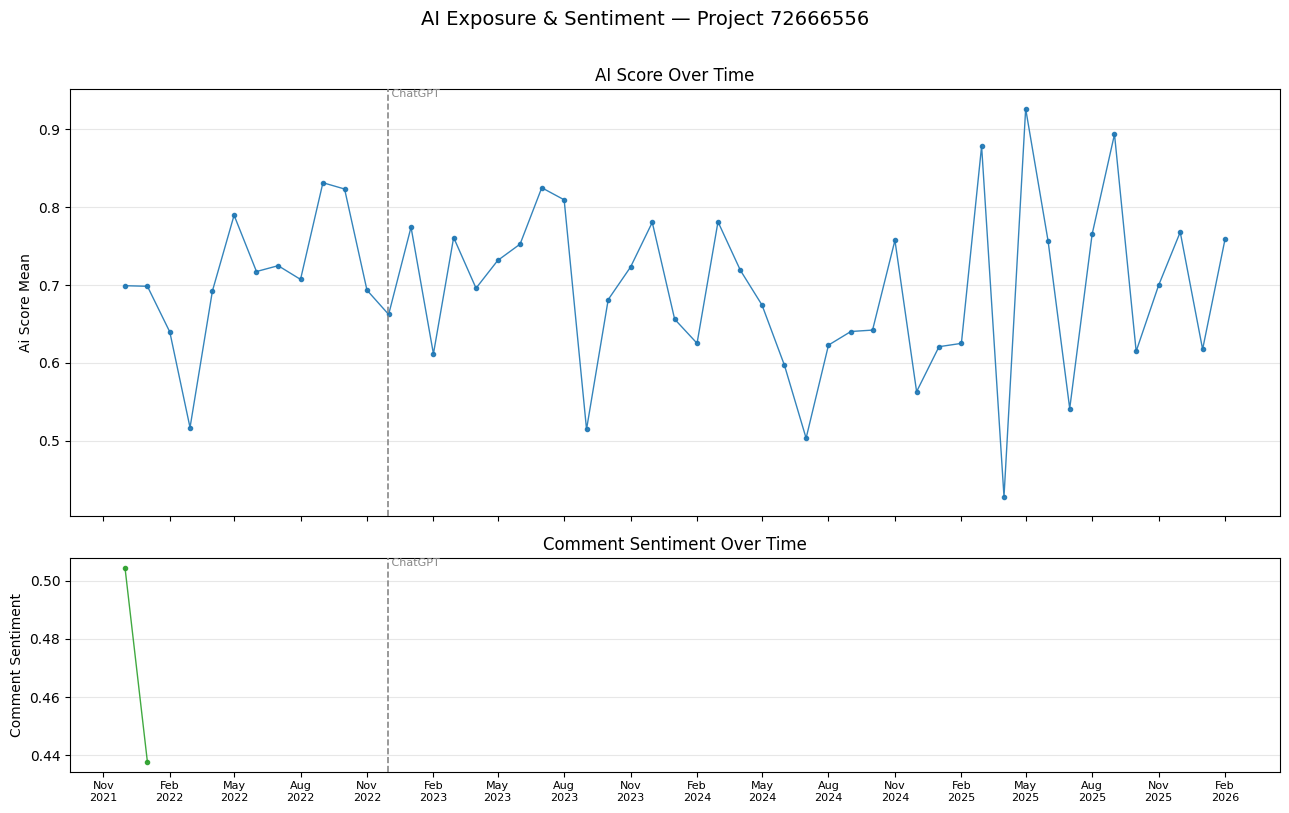

In [7]:
# Plot combined AI + Sentiment for one project
fig = plot_combined_ai_sentiment(
    panel,
    project_ids=[test_pid],
    ai_col='ai_score_mean',
    sentiment_col='comment_sentiment',
    markers=True,
    title=f"AI Exposure & Sentiment — Project {test_pid}",
)
plt.show()

---
## Cell B — Small Multi-Project Sample

Plot 5–10 projects with translucent lines to smoke-test the
multi-project overlay before scaling to the full population.

Plotting 10000 projects: ['72666556', '1144693322', '384168735', '1891933714', '2039121761', '167215725', '1302127607', '526794983', '1206100341', '705452410', '634138391', '1810548290', '1014219059', '910549467', '43823722', '1321854828', '612355252', '447973834', '1728993800', '21168872', '1809927993', '511984273', '1356786596', '1956562968', '240871415', '253248213', '1394308766', '1148110095', '1589750283', '1853270426', '684388000', '655112445', '1285627717', '461324763', '528732111', '56731993', '1602059434', '85727830', '1923705877', '215548897', '396135418', '677292838', '392350769', '161783388', '806750475', '1429107062', '594377064', '1506722315', '1765595584', '202877564', '1017473520', '604756610', '485870664', '578409559', '198429854', '1331805506', '1594001201', '761933903', '1757345856', '2074386957', '1723194488', '679850224', '1209837019', '1686581443', '1895436814', '1453800953', '1120050234', '1148118504', '1769636103', '169853509', '909489467', '1243903121', '160017

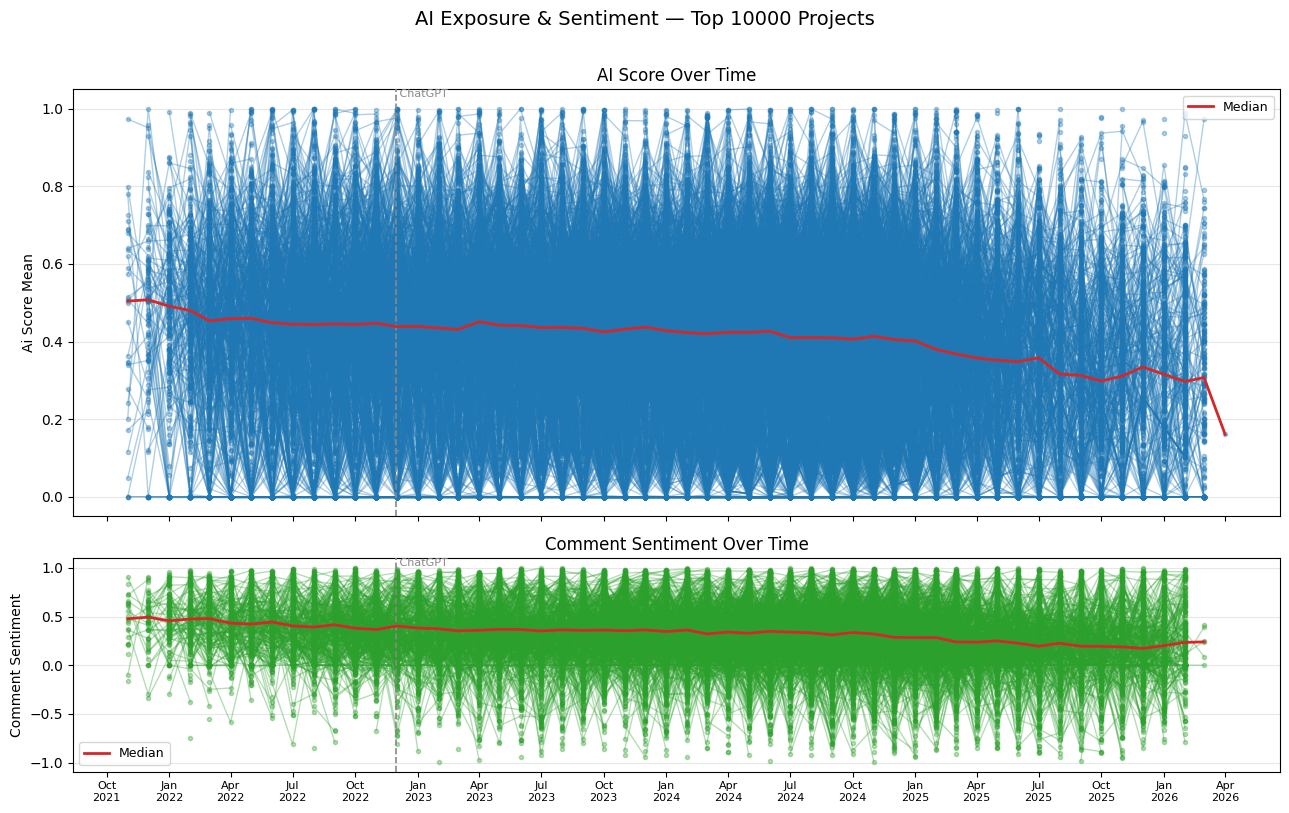

In [10]:
# Select top-N projects by observation count (fixed, reproducible selection)
N_SAMPLE = 10000
sample_pids = obs_per_project.head(N_SAMPLE).index.tolist()
print(f"Plotting {len(sample_pids)} projects: {sample_pids}")

fig = plot_combined_ai_sentiment(
    panel,
    project_ids=sample_pids,
    ai_col='ai_score_mean',
    sentiment_col='comment_sentiment',
    line_alpha=0.35,
    markers=True,
    show_median=True,
    title=f"AI Exposure & Sentiment — Top {N_SAMPLE} Projects",
)
plt.show()

---
## Optional: Faceted by Category

Small-multiples split by `category_unified` to parallel the
`C(category_unified)` control in the DID regressions.

In [ ]:
# Faceted plot by category (uses all projects in panel)
# Uncomment when ready — can be slow with many projects.

# fig = plot_combined_faceted(
#     panel,
#     facet_col='category_unified',
#     ai_col='ai_score_mean',
#     sentiment_col='comment_sentiment',
#     line_alpha=0.05,
#     show_median=True,
#     title='Exposure by Category',
# )
# plt.show()